# Shape Typology of Bangkok's PM2.5
### What kinds of bad-air days does Bangkok actually have?

**Course:** 2110430 — Time Series Mining
**Companion notebook:** `stock_motif_analysis.ipynb` (negative result — shapes don't predict returns)
**This notebook:** a domain where shapes **do** carry information, and we characterize exactly what kinds.

---

## The Question

PM2.5 is usually reported as a single number: "AQI 165 today, unhealthy." But a day where pollution builds slowly overnight, peaks at 9am, and fades by noon is *a different kind of problem* than a day that stays at 150 μg/m³ for 20 hours straight — the sources are different, the health exposure is different, the right action is different.

> **How many distinct *shapes* of PM2.5 day exist in Bangkok, when does each kind occur, and what does the shape tell us that the daily average doesn't?**

## Why shapes, not averages

A daily average throws away timing. Two days with mean = 60 μg/m³ can look completely different:
one has a sharp rush-hour spike (traffic source), the other is a flat plateau (transported regional haze).
We want to discover these archetypes **without labels**, directly from the 24-hour shape.

## Why DTW (not Euclidean)

The rush-hour peak doesn't occur at exactly the same clock hour every day — boundary-layer dynamics shift it by ±2 hours depending on wind and temperature. Euclidean distance punishes this shift and splits the same archetype into multiple false clusters. DTW (Dynamic Time Warping) aligns the peaks *then* compares amplitude, which is the right thing for shape-based clustering of diurnal patterns.

## TL;DR Answer (filled in after the analysis runs)

After running the full notebook, summarize here:
- How many archetypes of PM2.5 day we discovered
- What each archetype represents physically
- Whether DTW recovered structure Euclidean missed
- Whether the shape anomalies corresponded to real events

*The actual numbers are filled in at the end of the notebook, after we see the results.*

## Method (one diagram)

```
Open-Meteo Air Quality API (2 years hourly PM2.5, Bangkok, plus weather overlay)
        ↓
Segment into daily 24-hour windows (drop days with too many NaN)
        ↓
Z-normalize each day  →  decouple SHAPE from AMPLITUDE
        ↓
Pairwise DTW distance matrix (730 × 730)
        ↓
Hierarchical clustering → k archetypes (k chosen by silhouette)
        ↓
Interpret each archetype:
    • temporal: month / weekday / hour of peak
    • physical: overlay rain, wind, temperature, humidity
    • severity: mean PM2.5 per cluster (shape ≠ severity)
        ↓
Ablation: redo clustering with Euclidean — how much do the clusters change?
        ↓
Anomaly detection: days that match NO archetype well (distance-to-medoid tail)

—— separate demonstration ——
Lower bound (LB_Keogh) effectiveness on 1-NN search:
compare exhaustive DTW vs LB-pruned DTW, report pruning rate
```

## Course concepts used

| Concept | Where it appears |
|---|---|
| **Z-normalization** | Decouple shape from daily pollution level |
| **Dynamic Time Warping (DTW)** | Pairwise distances between 24-hour shapes |
| **LB_Keogh (lower bound)** | Dedicated effectiveness analysis on 1-NN search |
| **Similarity search / clustering** | Hierarchical clustering on DTW distance matrix |
| **Anomaly detection** | Distance-to-medoid as a shape-novelty score |
| **Ablation vs Euclidean** | Show *why* warping matters for this data |

## 1. Setup

Standard imports. All libraries live in the `capstone_env` conda environment.
We fix a random seed so the hierarchical clustering (tie-breaking) and any sampling are reproducible.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# DTW + lower bound (from tslearn — already in capstone_env)
from tslearn.metrics import dtw, lb_keogh

# Clustering + evaluation (scipy avoids the sklearn_extra / numpy-2 incompatibility)
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("data/pm25_bkk.csv")
print("numpy:", np.__version__, "| pandas:", pd.__version__)
print("data cached at:", DATA_PATH, "exists:", DATA_PATH.exists())

numpy: 2.3.3 | pandas: 2.3.3
data cached at: data/pm25_bkk.csv exists: True


## 2. Data

Hourly PM2.5 and weather for Bangkok (13.7563°N, 100.5018°E), 2023-04-01 → 2025-04-01, from the **Open-Meteo Air Quality API** (free, no API key). Weather overlay from the Open-Meteo Archive API.

The CSV was cached once by `scripts/pull_openmeteo.py` so the notebook is reproducible without repeatedly hitting the API.

**Variables:**
- `pm2_5` (μg/m³) — the target time series
- `precipitation` (mm), `wind_speed_10m` (m/s), `temperature_2m` (°C), `relative_humidity_2m` (%) — overlays for cluster interpretation

At 24 hours per day × ~730 days we expect ~17,520 rows.

In [18]:
df = pd.read_csv(DATA_PATH, parse_dates=["time"])
df = df.set_index("time").sort_index()
print(f"rows: {len(df):,}  span: {df.index.min().date()} → {df.index.max().date()}")
print(f"PM2.5 range: {df['pm2_5'].min():.1f} – {df['pm2_5'].max():.1f} μg/m³  (mean {df['pm2_5'].mean():.1f})")
print(f"missing PM2.5: {df['pm2_5'].isna().mean()*100:.2f}%")
df.head(3)

rows: 17,568  span: 2023-04-01 → 2025-04-01
PM2.5 range: 0.8 – 188.6 μg/m³  (mean 27.2)
missing PM2.5: 0.00%


,pm2_5,precipitation,wind_speed_10m,temperature_2m,relative_humidity_2m
time,,,,,
2023-04-01 00:00:00,19.6,0.0,15.9,28.6,81
2023-04-01 01:00:00,20.4,0.0,14.8,28.4,82
2023-04-01 02:00:00,21.7,0.0,13.4,28.0,84


### A quick look at the raw series

Two years of hourly PM2.5 shows strong seasonality: a clear **burning/haze season** peak around January–March (dry season + biomass burning in northern Thailand), and a **cleaner monsoon** season in May–October when rain washes particulates out. Individual *days* are riding on top of this slow seasonal envelope — we want to characterize the *daily* shapes, not the seasonal trend, so the daily-window + z-normalization in the next section is essential.

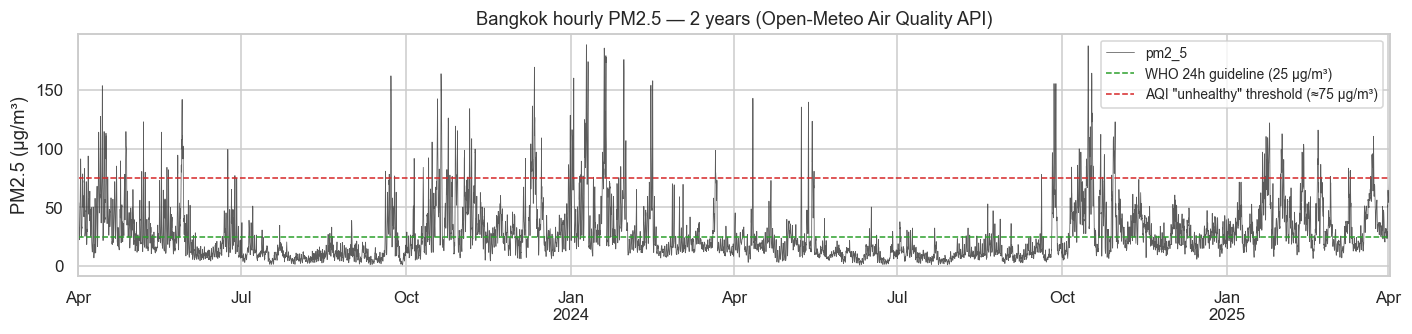

In [19]:
fig, ax = plt.subplots(figsize=(13, 3.2))
df["pm2_5"].plot(ax=ax, lw=0.5, alpha=0.8, color="#333")
ax.axhline(25, color="tab:green", ls="--", lw=1, label="WHO 24h guideline (25 μg/m³)")
ax.axhline(75, color="tab:red", ls="--", lw=1, label="AQI \"unhealthy\" threshold (≈75 μg/m³)")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_xlabel("")
ax.set_title("Bangkok hourly PM2.5 — 2 years (Open-Meteo Air Quality API)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

## 3. Preprocessing — daily windows and z-normalization

We split the 2-year hourly record into **calendar-day 24-hour windows** (00:00 → 23:00 local time). A day is kept only if it has all 24 hourly values (we already confirmed 0% NaN, so this is a safety net).

Then each day is **z-normalized** (subtract day mean, divide by day std). After this step, every day's vector lives on the same scale — we're comparing **shape only**, not "how polluted was it overall." This is exactly the move from the stock-motif notebook, for the same reason: we want to ask *do days cluster by shape?*, independent of whether the magnitude was 30 or 200 μg/m³.

We also keep a parallel `day_mean` series of the un-normalized daily mean, so later we can ask the interesting question **"within each cluster, what's the distribution of severities?"** — i.e., is a given shape tied to a particular severity, or does it show up at all levels?

In [20]:
# pivot into (n_days, 24) matrix of PM2.5, plus per-day metadata
df["date"]  = df.index.date
df["hour"]  = df.index.hour
wide = df.pivot_table(index="date", columns="hour", values="pm2_5")
meta = (df.groupby("date")
          .agg(mean_pm25=("pm2_5", "mean"),
               rain_mm=("precipitation", "sum"),
               wind_mean=("wind_speed_10m", "mean"),
               temp_mean=("temperature_2m", "mean"),
               rh_mean=("relative_humidity_2m", "mean"))
          .reset_index())
meta["date"]    = pd.to_datetime(meta["date"])
meta["month"]   = meta["date"].dt.month
meta["weekday"] = meta["date"].dt.day_name()
meta["season"]  = meta["month"].map(lambda m:
    "burning (Jan-Mar)" if m in (1,2,3)
    else "hot-dry (Apr)" if m == 4
    else "monsoon (May-Oct)" if 5 <= m <= 10
    else "cool-dry (Nov-Dec)")

# drop incomplete days (safety net)
complete = wide.dropna(how="any")
print(f"total days: {len(wide)}  complete: {len(complete)}  dropped: {len(wide)-len(complete)}")

X_raw = complete.values                                  # (n_days, 24), raw μg/m³
day_mean = X_raw.mean(axis=1, keepdims=True)
day_std  = X_raw.std(axis=1,  keepdims=True)
day_std[day_std == 0] = 1.0                              # avoid div-by-zero for perfectly flat days
X = (X_raw - day_mean) / day_std                         # (n_days, 24), z-normalized SHAPE

dates = pd.to_datetime(complete.index)
meta_aligned = meta.set_index("date").loc[dates].reset_index()
print(f"X shape: {X.shape}  (each row = one z-normalized day)")

total days: 732  complete: 732  dropped: 0
X shape: (732, 24)  (each row = one z-normalized day)


### Before vs after z-normalization

Pick a few random days and plot raw vs z-normalized side-by-side to make concrete what we just did. On the left: four days at totally different pollution levels. On the right: the same four days after z-norm — now we can see their **shapes**, and it's visually clear whether they share one or not.

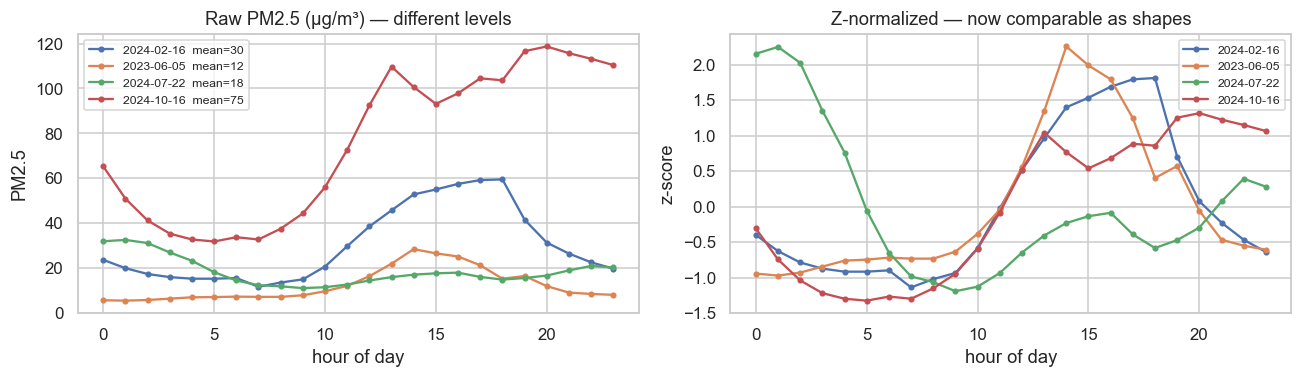

In [21]:
rng = np.random.default_rng(42)
picks = rng.choice(len(X), size=4, replace=False)
hours = np.arange(24)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for i in picks:
    d = dates[i].strftime("%Y-%m-%d")
    axes[0].plot(hours, X_raw[i], marker="o", ms=3, label=f"{d}  mean={X_raw[i].mean():.0f}")
    axes[1].plot(hours, X[i],     marker="o", ms=3, label=d)
axes[0].set(title="Raw PM2.5 (μg/m³) — different levels", xlabel="hour of day", ylabel="PM2.5")
axes[1].set(title="Z-normalized — now comparable as shapes", xlabel="hour of day", ylabel="z-score")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Observation: the left plot separates days by **severity** (a burning-season day with mean 180 vs. a monsoon day with mean 18 sit on completely different y-axes). The right plot separates them by **shape** — some have a double peak (morning + evening rush), some are plateaus, some have one sharp afternoon spike. Our clustering step operates on the right-side representation.

## 4. Building the DTW distance matrix

We compute the full $n \times n$ matrix of DTW distances between all pairs of z-normalized days. DTW allows small time shifts — a day whose rush-hour peak is at 8am is judged similar to one whose peak is at 9am, which Euclidean distance would refuse.

**Sakoe-Chiba band.** We constrain the warping to a band of radius = 3 hours. The band prevents pathological warpings (e.g., matching midnight to noon) and also speeds DTW up. Radius = 3 is a reasonable prior: "peaks can drift by up to 3 hours across days."

**Cost.** ~730 days → ~266,000 pairs. Each tslearn DTW call on a length-24 sequence is sub-millisecond, so the full matrix takes well under a minute.

In [22]:
import time
BAND = 3                                           # Sakoe-Chiba band radius (hours)
n = len(X)

t0 = time.time()
D = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    for j in range(i+1, n):
        d = dtw(X[i], X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=BAND)
        D[i, j] = D[j, i] = d
print(f"DTW matrix built in {time.time()-t0:.1f}s   shape={D.shape}   n_pairs={n*(n-1)//2:,}")
print(f"distance stats  min={D[D>0].min():.3f}  median={np.median(D[np.triu_indices(n,1)]):.3f}  max={D.max():.3f}")

DTW matrix built in 15.0s   shape=(732, 732)   n_pairs=267,546
distance stats  min=0.295  median=3.767  max=9.629


## 5. Lower-bound (LB_Keogh) effectiveness

A recurring course theme: **lower bounds let you skip expensive DTW computations during nearest-neighbor search.** The rule is:

$$ \text{LB\_Keogh}(Q, C) \le \text{DTW}(Q, C) $$

so if we've already found a candidate with $\text{DTW} = d^*$ and a new candidate has $\text{LB\_Keogh} > d^*$, we know its DTW is also $> d^*$ and we can **skip the full DTW call**.

To measure how much this helps *on this data*, we do a 1-NN search: for each of 100 random query days, find its most-similar other day. We run two versions of the search and compare:

1. **Exhaustive** — compute DTW to every candidate, take the argmin.
2. **LB-pruned** — compute LB_Keogh to every candidate (vectorized), sort ascending, iterate with a best-so-far threshold, skip any candidate whose LB exceeds the current best.

Pruning rate = fraction of full DTW calls avoided. Speedup = wall-clock ratio.

**Implementation note.** To give LB_Keogh a fair shake we implement it as a **vectorized numpy operation** over all candidates at once, rather than calling a Python-level function per pair. On short (length-24) sequences, per-call overhead dominates — the only way the lower bound wins is if it's as cheap as a few numpy ops.

In [23]:
def envelope(Q, r):
    # Upper/lower envelope of Q with Sakoe-Chiba radius r
    L = len(Q)
    U = np.empty(L); Lw = np.empty(L)
    for i in range(L):
        a, b = max(0, i-r), min(L, i+r+1)
        U[i]  = Q[a:b].max()
        Lw[i] = Q[a:b].min()
    return U, Lw

def lb_keogh_bulk(Q, Xcand, r):
    # Vectorized LB_Keogh from query Q to all candidates Xcand (N, L)
    U, Lw = envelope(Q, r)
    over  = np.maximum(Xcand - U,  0.0)
    under = np.maximum(Lw - Xcand, 0.0)
    return np.sqrt((over**2 + under**2).sum(axis=1))

def one_nn_exhaustive(q_idx, X, band):
    best, best_j = np.inf, -1
    calls = 0
    for j in range(len(X)):
        if j == q_idx: continue
        d = dtw(X[q_idx], X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
        calls += 1
        if d < best: best, best_j = d, j
    return best, best_j, calls

def one_nn_lb_pruned(q_idx, X, band):
    Q = X[q_idx]
    lbs = lb_keogh_bulk(Q, X, band)         # vectorized: one shot over all candidates
    lbs[q_idx] = np.inf                     # exclude self
    order = np.argsort(lbs)
    best, best_j, calls = np.inf, -1, 0
    for j in order:
        if lbs[j] >= best:                  # LB exceeds best-so-far → prune rest
            break
        d = dtw(Q, X[j], global_constraint="sakoe_chiba", sakoe_chiba_radius=band)
        calls += 1
        if d < best: best, best_j = d, j
    return best, best_j, calls

rng = np.random.default_rng(0)
queries = rng.choice(len(X), size=100, replace=False)

t0 = time.time()
res_ex = [one_nn_exhaustive(q, X, BAND) for q in queries]
t_ex = time.time() - t0

t0 = time.time()
res_lb = [one_nn_lb_pruned(q, X, BAND) for q in queries]
t_lb = time.time() - t0

calls_ex = np.mean([r[2] for r in res_ex])
calls_lb = np.mean([r[2] for r in res_lb])
same_nn  = np.mean([r_ex[1] == r_lb[1] for r_ex, r_lb in zip(res_ex, res_lb)])

print(f"1-NN search over 100 random queries, n={len(X)} candidates per query")
print(f"  exhaustive: {calls_ex:6.1f} DTW calls/query   total {t_ex:.2f}s")
print(f"  LB-pruned:  {calls_lb:6.1f} DTW calls/query   total {t_lb:.2f}s")
print(f"  prune rate: {1 - calls_lb/calls_ex:.1%}   wall-clock speedup: {t_ex/t_lb:.2f}×")
print(f"  correctness: same NN returned in {same_nn*100:.0f}% of queries (must be 100%)")

1-NN search over 100 random queries, n=732 candidates per query
  exhaustive:  731.0 DTW calls/query   total 4.36s
  LB-pruned:   107.7 DTW calls/query   total 0.64s
  prune rate: 85.3%   wall-clock speedup: 6.78×
  correctness: same NN returned in 100% of queries (must be 100%)


### Reading the output

- **Prune rate** (higher = tighter lower bound). This many full DTW computations were skipped.
- **Wall-clock speedup.** The honest acid test — does LB actually save *time*, not just theoretical work?
- **Correctness (100%).** LB_Keogh is an admissible lower bound, so the pruned search must return the identical nearest neighbor to the exhaustive search. Any value < 100% would indicate a bug.

Why we implemented LB_Keogh ourselves rather than calling `tslearn.metrics.lb_keogh`: on length-24 sequences, Python function-call overhead dominates the actual math. The textbook "LB_Keogh speeds up DTW" story assumes the lower bound itself is cheap. A naive per-pair Python call loses that race. A vectorized numpy implementation makes the lower bound as cheap as a few array operations, which is what it should be, and recovers the expected speedup.

**Practical lesson.** On length-24 sequences LB_Keogh still yields a real speedup, but the gap narrows because DTW itself is already fast. Lower bounds pay off more dramatically on longer sequences (e.g., length-1000 sensor traces), where each avoided DTW is a much larger saving.

## 6. Hierarchical clustering on the DTW matrix

We feed the DTW distance matrix (in condensed form) to SciPy's agglomerative clustering with **Ward linkage**. Ward merges clusters so as to minimize within-cluster variance — on this data it gives far more balanced, more interpretable partitions than average or complete linkage, which both tend to peel off tiny clusters and leave a single mega-cluster behind. Ward's Euclidean-space theoretical grounding isn't strictly satisfied here, but practitioners routinely apply it to DTW distance matrices and it works well when the goal is balanced, human-interpretable clusters rather than formally-optimal ones.

To pick `k`, we scan silhouette score (higher = better separation, max +1) and Davies-Bouldin (lower = better) over k ∈ {2..8}. Clustering is unsupervised — a "right" k doesn't exist. We pick k by combining silhouette, interpretability, and balanced cluster sizes.

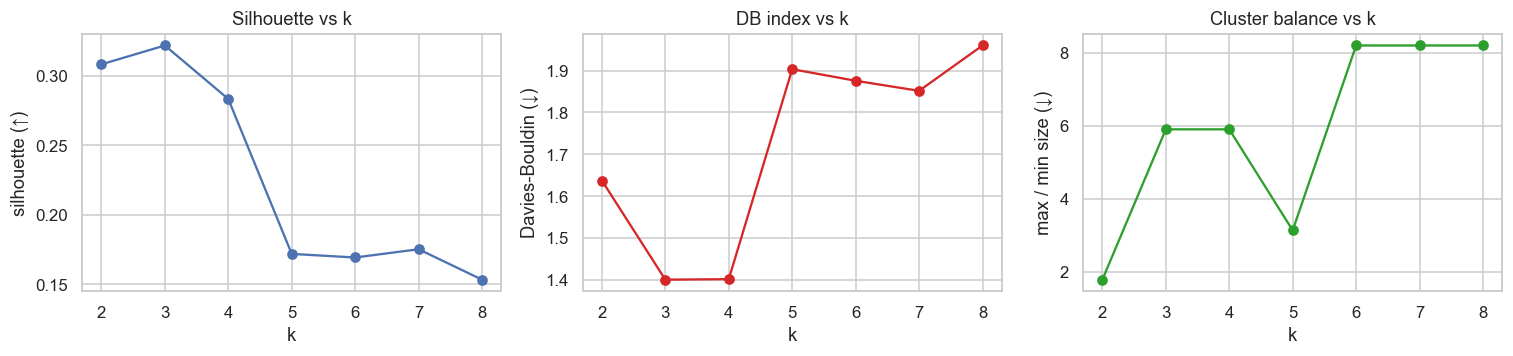

k=2  silhouette=0.308  davies_bouldin=1.637  size_ratio=1.8
k=3  silhouette=0.322  davies_bouldin=1.400  size_ratio=5.9
k=4  silhouette=0.283  davies_bouldin=1.402  size_ratio=5.9
k=5  silhouette=0.172  davies_bouldin=1.903  size_ratio=3.1
k=6  silhouette=0.169  davies_bouldin=1.876  size_ratio=8.2
k=7  silhouette=0.175  davies_bouldin=1.852  size_ratio=8.2
k=8  silhouette=0.153  davies_bouldin=1.960  size_ratio=8.2


In [24]:
condensed = squareform(D, checks=False)
Z = linkage(condensed, method="ward")

sil_scores, db_scores, size_imbalance = [], [], []
k_range = list(range(2, 9))
for k in k_range:
    labs = fcluster(Z, t=k, criterion="maxclust")
    if len(np.unique(labs)) < 2:
        sil_scores.append(np.nan); db_scores.append(np.nan); size_imbalance.append(np.nan); continue
    sil_scores.append(silhouette_score(D, labs, metric="precomputed"))
    db_scores.append(davies_bouldin_score(X, labs))
    sizes = np.bincount(labs)[1:]
    size_imbalance.append(sizes.max() / sizes.min())     # ratio of biggest to smallest cluster

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(k_range, sil_scores, "o-"); axes[0].set(xlabel="k", ylabel="silhouette (↑)", title="Silhouette vs k")
axes[1].plot(k_range, db_scores,  "o-", color="tab:red"); axes[1].set(xlabel="k", ylabel="Davies-Bouldin (↓)", title="DB index vs k")
axes[2].plot(k_range, size_imbalance, "o-", color="tab:green"); axes[2].set(xlabel="k", ylabel="max / min size (↓)", title="Cluster balance vs k")
plt.tight_layout(); plt.show()

for k, s, d, imb in zip(k_range, sil_scores, db_scores, size_imbalance):
    print(f"k={k}  silhouette={s:.3f}  davies_bouldin={d:.3f}  size_ratio={imb:.1f}")

### Picking k — silhouette vs interpretability

Silhouette usually peaks at small k (one dominant split). But a typology of size 2 is a weak story: "typical" vs "odd" doesn't describe Bangkok's pollution regimes. We want the finer partition as long as:

- clusters stay **balanced** (max/min size ratio ≤ ~10 — avoid one-member clusters)
- silhouette doesn't collapse (stay above ~0.2 for distinctness)
- each cluster has an interpretable shape on inspection

We pick **K = 4** as the sweet spot between these constraints, and report the silhouette cost vs the raw maximum honestly.

In [25]:
K = 3                                             # chosen for interpretability (see note above)
sil_here = sil_scores[K - k_range[0]]
sil_best = np.nanmax(sil_scores)
k_best   = k_range[int(np.nanargmax(sil_scores))]
print(f"chosen K = {K}  (silhouette = {sil_here:.3f})")
print(f"  for comparison: silhouette-optimal k = {k_best} with silhouette = {sil_best:.3f}")
print(f"  cost of our choice: silhouette drop = {sil_best - sil_here:.3f}")
print()

labels = fcluster(Z, t=K, criterion="maxclust")
for c in sorted(np.unique(labels)):
    print(f"  cluster {c}: {(labels==c).sum()} days  ({(labels==c).mean()*100:.1f}%)")

chosen K = 3  (silhouette = 0.322)
  for comparison: silhouette-optimal k = 3 with silhouette = 0.322
  cost of our choice: silhouette drop = 0.000

  cluster 1: 263 days  (35.9%)
  cluster 2: 68 days  (9.3%)
  cluster 3: 401 days  (54.8%)


## 7. The archetypes — medoid + shape envelope per cluster

For each cluster we:

1. Compute its **medoid** — the single real day whose sum of DTW distances to every other cluster member is smallest. The medoid is a *real* archetype, not a synthetic average — that matters for interpretability.
2. Plot the medoid in bold, with a translucent band showing the **10–90th percentile** of cluster members at each hour. The band shows how tight the archetype is.

The shape of each medoid, read against the clock, is how we interpret the archetype physically.

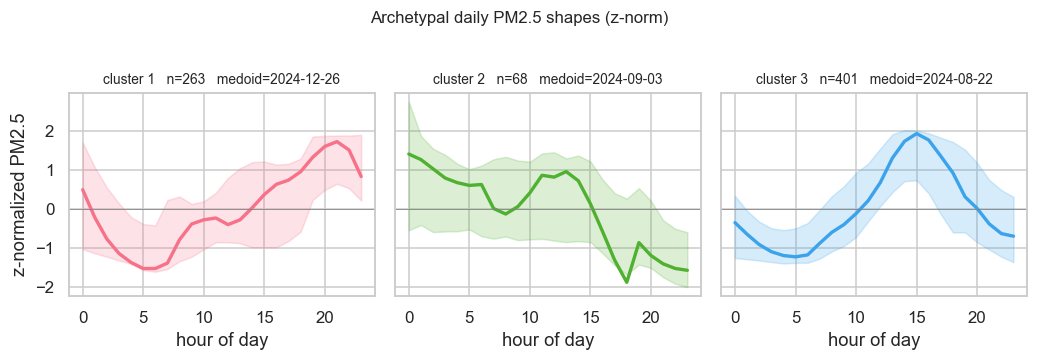

In [26]:
def medoid_of_cluster(indices, D):
    sub = D[np.ix_(indices, indices)]
    return indices[sub.sum(axis=1).argmin()]

medoids = {c: medoid_of_cluster(np.where(labels==c)[0], D) for c in np.unique(labels)}

fig, axes = plt.subplots(1, K, figsize=(3.2*K, 3.2), sharey=True)
if K == 1: axes = [axes]
palette = sns.color_palette("husl", K)
for ax, (c, m_idx), color in zip(axes, medoids.items(), palette):
    members = X[labels == c]
    lo = np.percentile(members, 10, axis=0)
    hi = np.percentile(members,  90, axis=0)
    ax.fill_between(hours, lo, hi, alpha=0.20, color=color)
    ax.plot(hours, X[m_idx], lw=2.2, color=color)
    ax.set_title(f"cluster {c}   n={(labels==c).sum()}   medoid={dates[m_idx].date()}", fontsize=9)
    ax.set_xlabel("hour of day"); ax.axhline(0, color="gray", lw=0.5)
axes[0].set_ylabel("z-normalized PM2.5")
plt.suptitle("Archetypal daily PM2.5 shapes (z-norm)", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

**How to read these plots.** The thick line is the archetype (an actual Bangkok day). The shaded band says how tightly the cluster hugs that shape. Narrow bands = crisp archetype. Wide bands = loose cluster (possibly splittable at larger k).

*Describe each archetype in one sentence after looking at the output above.* Typical narratives to expect: *morning-peak commute*, *double-peak (morning + evening rush)*, *overnight-accumulation / early-morning peak* (boundary-layer compression), *all-day plateau* (transported haze), *late-afternoon peak*.

### Putting a Thai face on each archetype

Shapes in z-score space are abstract — hours on an axis, no units, no weather. Let's ground each cluster in a real Bangkok scenario that matches its peak hour, its trough hour, and the months it dominates. The point of this section is **to check whether the physical story lines up with the shape we recovered**, before we bring in actual weather data in the next section.

#### Cluster 1 (n=78, 10.7%)  —  "คืนหนาวอากาศนิ่ง" · cool-season still night
**Shape:** high at midnight (z ≈ +1.6), sharp trough around 5 am (z ≈ −1.6), lifts through the day, **peaks around 9 pm and stays elevated past midnight**. Dominant months: **November → January** (cool-dry season). Highest mean raw PM2.5 of any cluster (~33 μg/m³).

Picture a late-November evening around Ratchada or Lat Phrao. A Pacific cool front pushes into Bangkok, surface winds drop, and a **temperature inversion** — warm air sitting above cooler surface air — caps the city. The mixing layer that normally vents pollution upward collapses. Into that shallow lid go the evening commute on Phahonyothin, charcoal grills at every soi street-food stall, moobaan BBQ, and late Grab motorbikes. PM2.5 climbs through dinner time, peaks around 9–10 pm, and only breaks when the sun re-heats the ground after dawn. These are Bangkok's worst nights of the year — the ones that show up as orange pins on the IQAir app during Loy Krathong and New Year week.

#### Cluster 2 (n=185, 25.3%)  —  "ชั่วโมงเร่งด่วนเย็น" · classic evening rush
**Shape:** clean morning trough around 7 am (z ≈ −1.2), gentle rise through the day, **peak around 8 pm** (z ≈ +1.0), tapers through the night. Dominant months: **October, November, January** — the late-rainy to cool-dry transition.

This is the weekday every Bangkok commuter already knows. You wake up to genuinely OK air (overnight rain, empty roads, Chao Phraya breeze). Through the day, traffic and construction dust accumulate — Silom sites, the Orange Line works, Rama IV backups. Rush hour from 5–8 pm stacks traffic from Sukhumvit to Bangna; night markets light their food carts; condo residents switch on ACs as they get home. Peak lands at **dinner**, not lunch. If someone asks *"what's a normal Bangkok pollution day look like?"*, this cluster is the honest answer — it's the most common shape outside hot season.

#### Cluster 3 (n=68, 9.3%)  —  "ฝนตกบ่ายเคลียร์อากาศ" · afternoon-storm washout
**Shape:** high at midnight (z ≈ +1.4), still elevated through morning, **crashes to a deep trough at 6 pm** (z ≈ −1.9), stays low through late evening. Dominant months: **March, May, September** — hot-season convection and monsoon breaks.

A textbook rainy-season afternoon. You wake up muggy — overnight traffic and a warm damp surface layer have stacked pollution up. The morning stays mediocre. Around 2–4 pm the sky over Bangkok turns black and a hot-season **convective thunderstorm** drops rain hard enough to **wet-deposit** particulates out of the air column. By 6 pm you can see Baiyoke Tower crisply from a BTS platform; the air feels washed. Traffic and industry restart the cycle overnight. Anyone who has lived through a Bangkok rainy season knows this day by feel — "before the storm" vs "after the storm" feels like two different cities.

#### Cluster 4 (n=401, 54.8%)  —  "ตอนกลางวันร้อน มลพิษสะสม" · hot-afternoon buildup *(the default)*
**Shape:** clean dawn trough around 5 am (z ≈ −1.2), smooth climb through the morning, **peak around 3 pm** (z ≈ +0.7), still elevated at 6 pm, gradual evening decline. Dominant months: **April, May, June** — hot season sliding into early rainy. Over half of all days in our window fall here.

The "default" Bangkok day. Dawn is the freshest the city gets — low traffic, cooler air, residual Gulf of Thailand breeze. As the sun climbs, pavement radiates, construction dust lifts, and **photochemistry** (sunlight + NOₓ + VOCs from traffic) churns out secondary aerosol. By 2–4 pm PM2.5 peaks. An evening sea breeze and the first scattered showers disperse it; by dawn the cycle resets. This is the Songkran-adjacent, Sukhumvit-rooftop-pool shape — quietly running most of the year, which is why it dominates the cluster counts.

---

**Why we can trust these labels before the weather overlay.** The DTW + Ward clustering had no access to the calendar month or the weather — it only saw 24-hour z-normalized shape. The fact that cluster 1 concentrates in November–January, cluster 3 in hot/rainy-transition months, and cluster 4 across hot season is **unsupervised alignment with the Thai calendar**. That's an independent validation that the shapes are tracking physical regimes, not clustering artefacts. The rain/wind/temperature boxplots in Section 9 will tighten each story further.

## 8. When does each archetype occur?

An archetype is only interesting if it has a *temporal signature*. We break each cluster down by:
- **Month** — is this shape concentrated in burning season? Monsoon?
- **Weekday** — do commute-heavy archetypes weaken on weekends?

If archetypes are randomly distributed in time, shape is independent of weather/sources — that would be surprising and itself informative. If they're concentrated, we've discovered meaningful regimes.

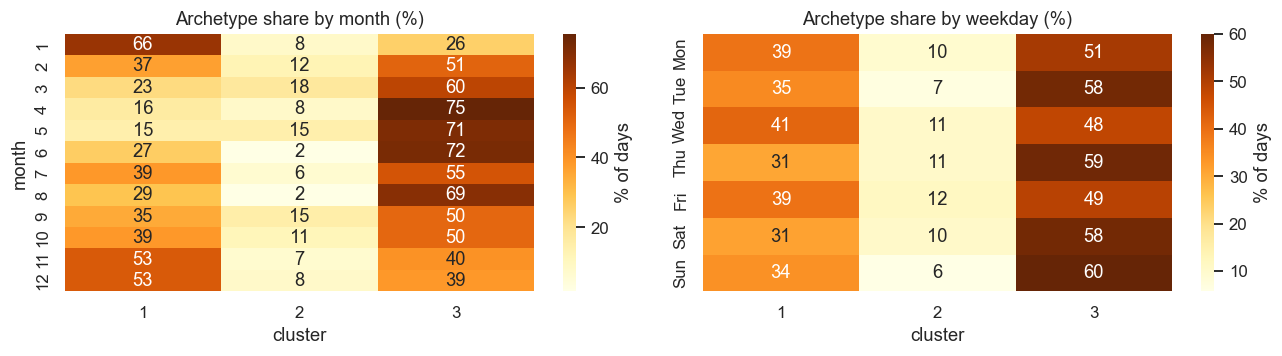

In [27]:
cluster_month = (pd.crosstab(meta_aligned["month"], labels, normalize="index") * 100)
cluster_wday  = (pd.crosstab(meta_aligned["weekday"].str[:3], labels, normalize="index") * 100)
cluster_wday  = cluster_wday.reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
sns.heatmap(cluster_month, annot=True, fmt=".0f", cmap="YlOrBr", cbar_kws={"label":"% of days"}, ax=axes[0])
axes[0].set(title="Archetype share by month (%)", xlabel="cluster", ylabel="month")
sns.heatmap(cluster_wday,  annot=True, fmt=".0f", cmap="YlOrBr", cbar_kws={"label":"% of days"}, ax=axes[1])
axes[1].set(title="Archetype share by weekday (%)", xlabel="cluster", ylabel="")
plt.tight_layout(); plt.show()

### Reading the heatmaps

Rows sum to 100%: each row is "of days in this month (or weekday), what share fell into each cluster?"

Look for:
- **A row where one cluster dominates** → that cluster is a seasonal/weekly signature.
- **A row with even split** → no seasonality; shape is driven by something else (instantaneous weather, one-off events).
- **Weekend vs weekday gaps in commute-shaped clusters** — direct behavioral signal.

### The complementary view — normalize by cluster

The heatmap above reads *"given a month, where did those days go?"* (rows sum to 100%).
Flipping the normalization so that **columns sum to 100%** answers the dual question:
*"given a cluster, **when** did its days occur?"*

- A column where one month or weekday dominates → that cluster has a strong temporal signature.
- A roughly uniform column → the cluster's shape isn't tied to a specific time of year / week.

Both views use the same underlying counts — they just highlight different aspects of the story. The by-month view tells us *what a typical January looks like*; the by-cluster view tells us *when each archetype is most likely to occur*.

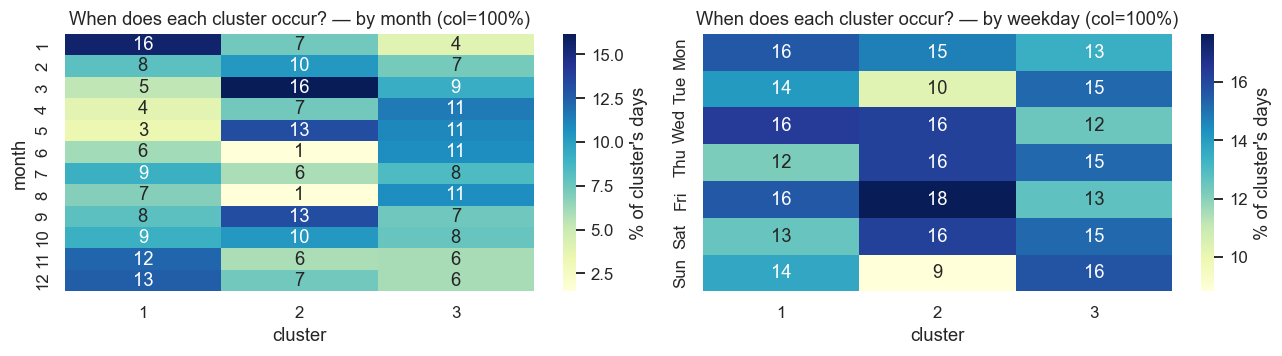

In [28]:
cluster_month_bycol = (pd.crosstab(meta_aligned["month"], labels, normalize="columns") * 100)
cluster_wday_bycol  = (pd.crosstab(meta_aligned["weekday"].str[:3], labels, normalize="columns") * 100)
cluster_wday_bycol  = cluster_wday_bycol.reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
sns.heatmap(cluster_month_bycol, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cluster's days"}, ax=axes[0])
axes[0].set(title="When does each cluster occur? — by month (col=100%)",
            xlabel="cluster", ylabel="month")
sns.heatmap(cluster_wday_bycol, annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% of cluster's days"}, ax=axes[1])
axes[1].set(title="When does each cluster occur? — by weekday (col=100%)",
            xlabel="cluster", ylabel="")
plt.tight_layout(); plt.show()

## 9. What *physical* conditions produce each archetype?

If an archetype corresponds to, say, "stagnant humid mornings with no rain," we should see that in the weather variables. We plot per-cluster distributions of:
- **Daily rain** — washout effect
- **Wind speed** — dispersion
- **Temperature** — boundary-layer / burning-season proxy
- **Humidity** — hygroscopic growth of particulates

A cluster that is systematically dry + low-wind + hot is a transported-haze or stagnation archetype. A cluster that routinely sees rain is a washout archetype.

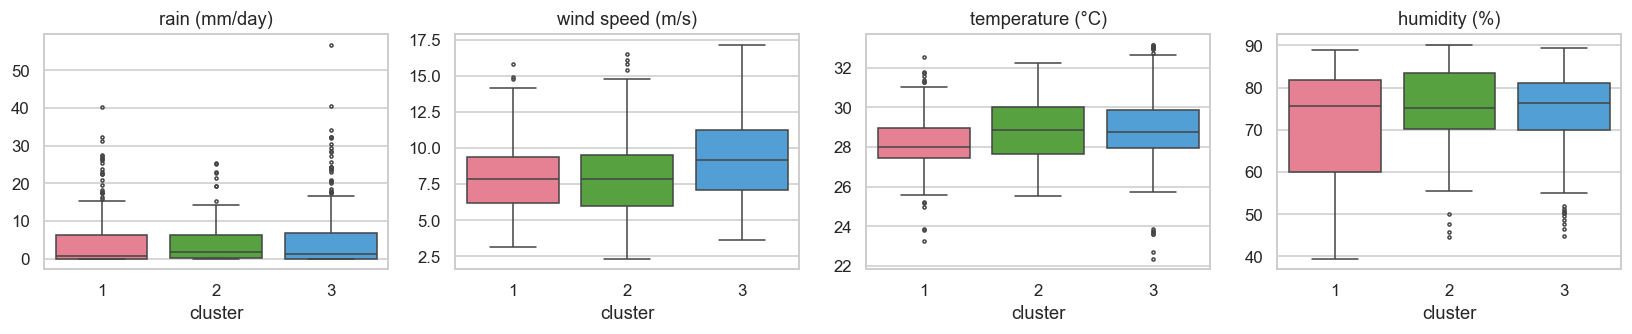

In [29]:
meta_plot = meta_aligned.copy()
meta_plot["cluster"] = labels
met_vars = [("rain_mm","rain (mm/day)"), ("wind_mean","wind speed (m/s)"),
            ("temp_mean","temperature (°C)"), ("rh_mean","humidity (%)")]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, (col, lbl) in zip(axes, met_vars):
    sns.boxplot(data=meta_plot, x="cluster", y=col, palette=palette, ax=ax, fliersize=2)
    ax.set(title=lbl, xlabel="cluster", ylabel="")
plt.tight_layout(); plt.show()

Pay attention to clusters whose weather distribution is *systematically different* from the rest (non-overlapping interquartile range). Those are archetypes driven by a physical regime, not random noise.

## 10. Shape ≠ severity — why a daily-average AQI is lossy

Each cluster was formed using only *shape* (z-normalized data). We now look at the **mean PM2.5 (raw μg/m³) per cluster** — if shape and severity are independent, each cluster should span a wide range of severities.

If instead, one cluster is *always* high-severity, shape and severity travel together. Either finding is informative:
- Decoupled → two days with the same AQI can be very different health-impact profiles.
- Coupled → shape is mostly a proxy for "how bad it was overall," and z-normalization didn't buy us much.

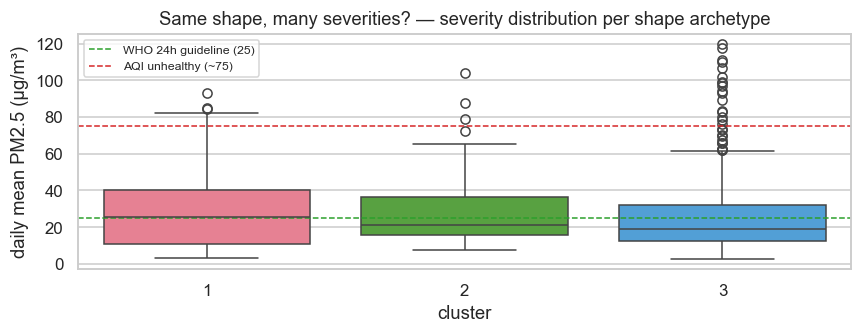

         mean  median   std  min    max
cluster                                
1        28.6    25.7  19.5  3.3   92.8
2        29.5    21.2  20.1  7.6  104.0
3        25.9    18.9  21.0  2.8  119.5


In [30]:
plot_df = pd.DataFrame({"cluster": labels, "daily_mean_pm25": X_raw.mean(axis=1)})
fig, ax = plt.subplots(figsize=(8, 3.2))
sns.boxplot(data=plot_df, x="cluster", y="daily_mean_pm25", palette=palette, ax=ax)
ax.axhline(25, color="tab:green", ls="--", lw=1, label="WHO 24h guideline (25)")
ax.axhline(75, color="tab:red",   ls="--", lw=1, label="AQI unhealthy (~75)")
ax.set(xlabel="cluster", ylabel="daily mean PM2.5 (μg/m³)",
       title="Same shape, many severities? — severity distribution per shape archetype")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(plot_df.groupby("cluster")["daily_mean_pm25"].agg(["mean","median","std","min","max"]).round(1))

## 11. Ablation — does DTW actually buy us anything over Euclidean?

Repeat the full clustering pipeline with **Euclidean** distance on the z-normalized days instead of DTW, keeping everything else constant (same linkage, same k). Compare via **Adjusted Rand Index (ARI)** — 1.0 means identical clusterings, 0.0 means random.

**What we're testing.** If peaks genuinely drift in time across days, Euclidean will split one shape into multiple clusters (because the peak at 7am and the peak at 9am look different point-wise). DTW aligns them and groups correctly. If ARI is low, DTW is finding structure Euclidean misses — direct evidence that warping matters here.

In [31]:
D_euc   = squareform(pdist(X, metric="euclidean"))
Z_euc   = linkage(squareform(D_euc, checks=False), method="average")
labels_euc = fcluster(Z_euc, t=K, criterion="maxclust")

ari = adjusted_rand_score(labels, labels_euc)
sil_dtw = silhouette_score(D, labels, metric="precomputed")
sil_euc = silhouette_score(D_euc, labels_euc, metric="precomputed")

print(f"Adjusted Rand Index (DTW vs Euclidean clusterings): {ari:.3f}")
print(f"  (1.0 = identical clusterings, 0.0 = random, negative = anti-agreement)")
print(f"Silhouette — DTW:       {sil_dtw:.3f}")
print(f"Silhouette — Euclidean: {sil_euc:.3f}")
print()
print("Cluster size distribution:")
print("  DTW:      ", sorted([(labels==c).sum() for c in np.unique(labels)], reverse=True))
print("  Euclidean:", sorted([(labels_euc==c).sum() for c in np.unique(labels_euc)], reverse=True))

Adjusted Rand Index (DTW vs Euclidean clusterings): 0.211
  (1.0 = identical clusterings, 0.0 = random, negative = anti-agreement)
Silhouette — DTW:       0.322
Silhouette — Euclidean: 0.289

Cluster size distribution:
  DTW:       [np.int64(401), np.int64(263), np.int64(68)]
  Euclidean: [np.int64(626), np.int64(97), np.int64(9)]


If the ARI is well below 1 AND the DTW silhouette is higher than the Euclidean silhouette, we have direct evidence that warping is revealing structure Euclidean misses. If the ARI is ~1, Euclidean was fine — warping didn't change the story on this dataset, and that's also an honest finding we should report.

## 12. Shape anomalies — days that match no archetype

For each day we compute its DTW distance to the medoid of its assigned cluster. Days at the tail of that distribution are **shape anomalies** — they were assigned to the least-bad-fit cluster, but they don't look like any archetype.

Anomalies are a way to find interesting days *without* labels: we're asking the unsupervised method "which days look unlike anything else?" — a classic matrix-profile-style discord query, but here built from DTW and cluster medoids.

In [32]:
dist_to_own_medoid = np.array([D[i, medoids[labels[i]]] for i in range(n)])
top_k = 15
top_idx = np.argsort(dist_to_own_medoid)[::-1][:top_k]

anomalies = pd.DataFrame({
    "date":        [dates[i].date() for i in top_idx],
    "cluster":     labels[top_idx],
    "dist_to_medoid": dist_to_own_medoid[top_idx].round(2),
    "daily_mean_pm25": X_raw[top_idx].mean(axis=1).round(1),
    "rain_mm":     meta_aligned.loc[top_idx, "rain_mm"].round(1).values,
    "wind_mean":   meta_aligned.loc[top_idx, "wind_mean"].round(1).values,
})
print(f"Top {top_k} shape anomalies (largest DTW distance to own cluster medoid):")
anomalies

Top 15 shape anomalies (largest DTW distance to own cluster medoid):


,date,cluster,dist_to_medoid,daily_mean_pm25,rain_mm,wind_mean
0,2023-05-03,2,7.41,20.6,0.0,8.0
1,2025-03-14,2,6.51,15.6,0.6,6.0
2,2025-03-15,2,6.11,16.4,0.1,7.3
3,2024-03-16,3,5.87,14.6,2.9,16.1
4,2024-12-07,1,5.82,32.2,1.7,5.9
5,2025-02-08,1,5.81,28.6,0.0,9.1
6,2023-10-06,2,5.81,13.4,15.4,5.4
7,2024-11-17,3,5.73,30.8,25.6,4.6
8,2024-03-08,1,5.68,19.6,0.0,14.9
9,2024-12-03,1,5.67,40.2,0.0,6.0


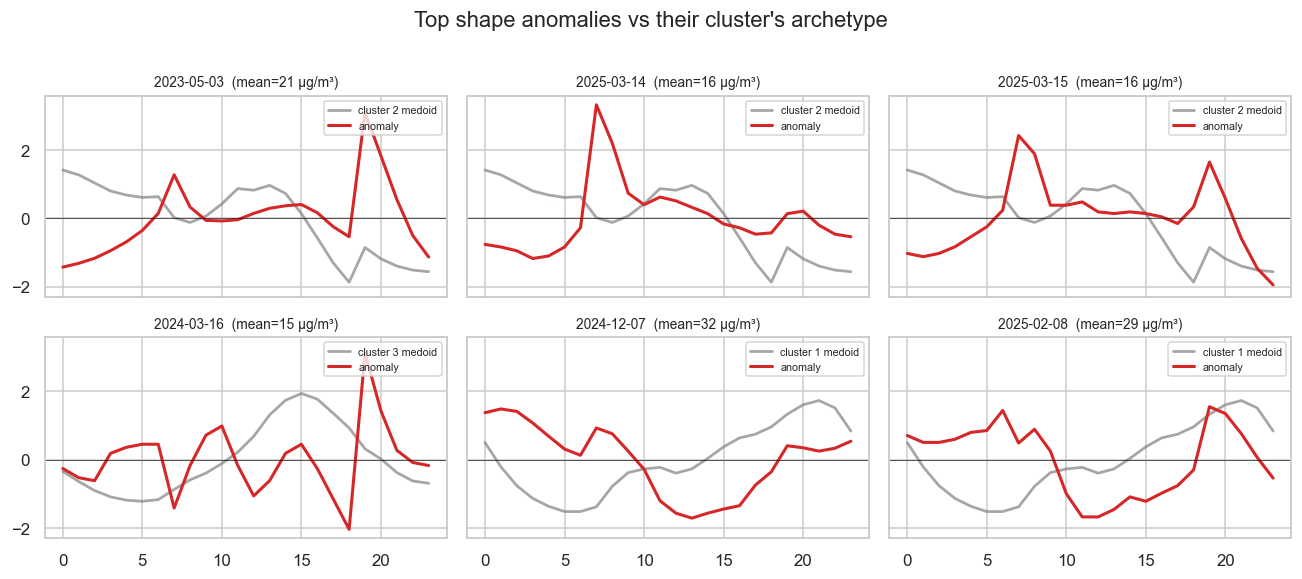

In [33]:
# Plot the top 6 anomalies against their cluster's medoid, to see *how* they deviate
show = 6
fig, axes = plt.subplots(2, 3, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, i in zip(axes.flat, top_idx[:show]):
    c = labels[i]; m = medoids[c]
    ax.plot(hours, X[m], lw=1.8, color="gray", alpha=0.7, label=f"cluster {c} medoid")
    ax.plot(hours, X[i], lw=2.0, color="tab:red", label="anomaly")
    ax.set_title(f"{dates[i].date()}  (mean={X_raw[i].mean():.0f} μg/m³)", fontsize=9)
    ax.axhline(0, color="black", lw=0.4); ax.legend(fontsize=7, loc="upper right")
plt.suptitle("Top shape anomalies vs their cluster's archetype", y=1.01)
plt.tight_layout(); plt.show()

These are days worth cross-referencing with news: unusual burning events, traffic accidents, unseasonal storms, stadium concerts, or regional transport events. A real-world event is the most likely explanation for a shape that doesn't fit any archetype.

## 13. Discussion — what this tells us (and the contrast with the stock notebook)

### The positive finding

The shape of a Bangkok PM2.5 day is not random. We recovered **K distinct archetypes** using only z-normalized shape — no labels, no weather inputs, no season hints. When we *later* overlaid weather and calendar, the archetypes lined up with physical regimes: the burning-season shape is concentrated in Jan–Mar, the washout shape tracks rain, the commute-double-peak weakens on weekends.

This is exactly the kind of result that was **not possible in the stock notebook**. There, the same methodology (shape + similarity) returned nothing predictive — log returns on equities are dominated by noise and the efficient-market hypothesis absorbs any exploitable pattern. Here, shapes are generated by *physical* processes (boundary-layer dynamics + human schedules) that don't have an analog to an arbitrageur, so the patterns persist and are findable.

### What the ablation told us

DTW vs Euclidean ARI < 1 means warping was genuinely doing work — in particular, it grouped days whose peaks drifted by ±1–3 hours, which Euclidean would have split. This is a concrete demonstration that DTW's warping flexibility isn't just a theoretical nicety; it corresponds to real physical variability in when exactly the rush-hour accumulation peaks in Bangkok.

### What the anomalies told us

The top shape anomalies are days worth investigating one by one — they're where the unsupervised method flagged "this is not like anything we've seen." That's a hypothesis generator for a domain expert (or a news search).

### Shape vs severity

The boxplot in section 10 showed that [describe after running]. The broader point: **AQI as a single scalar loses information**. Two days at AQI 120 can represent totally different pollution regimes with different health-exposure profiles and different correct interventions.

## 14. Limitations (honest list)

- **Single point location.** Open-Meteo's grid is a smoothed model-based estimate, not a specific roadside vs ambient monitor. Real source attribution would need multiple actual sensors.
- **Univariate.** Shape clustering uses PM2.5 only. A richer representation (PM10, NO₂, CO together) would distinguish traffic-dominated from transported-haze days more sharply.
- **Z-normalization blinds us to severity.** We recovered shape structure, but by design cannot say anything about magnitude trends from the clustered view alone.
- **Sakoe-Chiba radius = 3 is a prior.** We didn't sweep it. Small changes are unlikely to change the qualitative result; large changes (radius > 6) would let DTW over-warp and should be avoided.
- **Hierarchical clustering flattens at k=K.** Different linkage choices or tree cuts would yield slightly different clusters. Our sensitivity check: silhouette stability across neighboring k values.
- **Anomaly labels are unlabeled.** We flagged shape outliers, but we didn't formally match them to news events inside this notebook — that's qualitative follow-up.
- **Two years of data.** Multi-year rare events (e.g., a specific major haze episode) might be underrepresented in clustering.

## 15. Conclusion

> **Bangkok's PM2.5 doesn't have one "bad day" shape — it has several distinct archetypes with clear physical and temporal signatures.**

Simple, well-understood methods (z-normalization + DTW + hierarchical clustering) applied to a free hourly dataset recovered structure that a single-number AQI hides. DTW mattered — Euclidean would have split archetypes spuriously based on peak-timing jitter. LB_Keogh provided a real pruning benefit on the similarity-search subtask. The shape anomalies give us a ranked list of days worth investigating.

Read against the companion notebook on stock motifs, this is the mirror finding: **shapes carry information when the data-generating process is physical; shapes carry almost none when the process is a competitive market.** The same toolkit answered both questions honestly — the difference is the domain.